In [47]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meghawadhwani/personal-health-indicators-and-lifestyle-vitals")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'personal-health-indicators-and-lifestyle-vitals' dataset.
Path to dataset files: /kaggle/input/personal-health-indicators-and-lifestyle-vitals


In [48]:
import pandas as pd
import os

# List all files in the downloaded dataset directory
files = os.listdir(path)
print("Files in dataset directory:", files)

# Find the first CSV file in the directory
csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    csv_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_file_path)
    print(f"Successfully loaded: {csv_files[0]}")
else:
    print("No CSV file found in the dataset directory.")

Files in dataset directory: ['health_sensor.csv']
Successfully loaded: health_sensor.csv


In [49]:
df.head()

,age,sleep_hours,work_hours,screen_time,water_intake,exercise,meals_per_day,caffeine_intake,social_interaction,heart_rate,spo2,temperature,blood_pressure,cholesterol,glucose,insulin,stress_level,mental_health_score,target
0,56,4.950843,9.799390,6.655425,2.396012,1,2,1,1,84.476567,97.013451,36.889154,150.533171,225.867421,123.244423,28.554230,8.212414,4.511139,1
1,46,5.739277,6.050878,7.122773,1.500000,1,3,0,1,76.988263,97.355122,36.938951,153.188912,196.008205,95.401836,30.201545,5.616521,6.370851,0
2,32,6.862036,9.726273,8.686619,1.741437,1,2,1,1,78.963376,96.336875,36.808369,152.351626,197.222843,109.124052,28.255472,6.845342,4.345828,0
3,60,7.493963,7.585901,6.367793,3.281423,0,4,1,1,86.397313,96.774124,36.796904,143.764268,212.259231,106.022372,32.466890,5.740141,5.073400,0
4,25,6.113116,5.780637,7.693597,2.589713,1,3,0,1,74.605210,97.610242,36.423819,125.623723,181.037041,84.759179,17.951963,3.553031,9.313631,0


In [50]:
df.columns

Index(['age', 'sleep_hours', 'work_hours', 'screen_time', 'water_intake',
       'exercise', 'meals_per_day', 'caffeine_intake', 'social_interaction',
       'heart_rate', 'spo2', 'temperature', 'blood_pressure', 'cholesterol',
       'glucose', 'insulin', 'stress_level', 'mental_health_score', 'target'],
      dtype='object')

In [51]:
x= df.drop(columns='target')

In [52]:
y = df['target']

In [53]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10000 non-null  int64  
 1   sleep_hours          10000 non-null  float64
 2   work_hours           10000 non-null  float64
 3   screen_time          10000 non-null  float64
 4   water_intake         10000 non-null  float64
 5   exercise             10000 non-null  int64  
 6   meals_per_day        10000 non-null  int64  
 7   caffeine_intake      10000 non-null  int64  
 8   social_interaction   10000 non-null  int64  
 9   heart_rate           10000 non-null  float64
 10  spo2                 10000 non-null  float64
 11  temperature          10000 non-null  float64
 12  blood_pressure       10000 non-null  float64
 13  cholesterol          10000 non-null  float64
 14  glucose              10000 non-null  float64
 15  insulin              10000 non-null  

In [54]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: target
Non-Null Count  Dtype
--------------  -----
10000 non-null  int64
dtypes: int64(1)
memory usage: 78.3 KB


In [55]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  10000 non-null  int64  
 1   sleep_hours          10000 non-null  float64
 2   work_hours           10000 non-null  float64
 3   screen_time          10000 non-null  float64
 4   water_intake         10000 non-null  float64
 5   exercise             10000 non-null  int64  
 6   meals_per_day        10000 non-null  int64  
 7   caffeine_intake      10000 non-null  int64  
 8   social_interaction   10000 non-null  int64  
 9   heart_rate           10000 non-null  float64
 10  spo2                 10000 non-null  float64
 11  temperature          10000 non-null  float64
 12  blood_pressure       10000 non-null  float64
 13  cholesterol          10000 non-null  float64
 14  glucose              10000 non-null  float64
 15  insulin              10000 non-null  

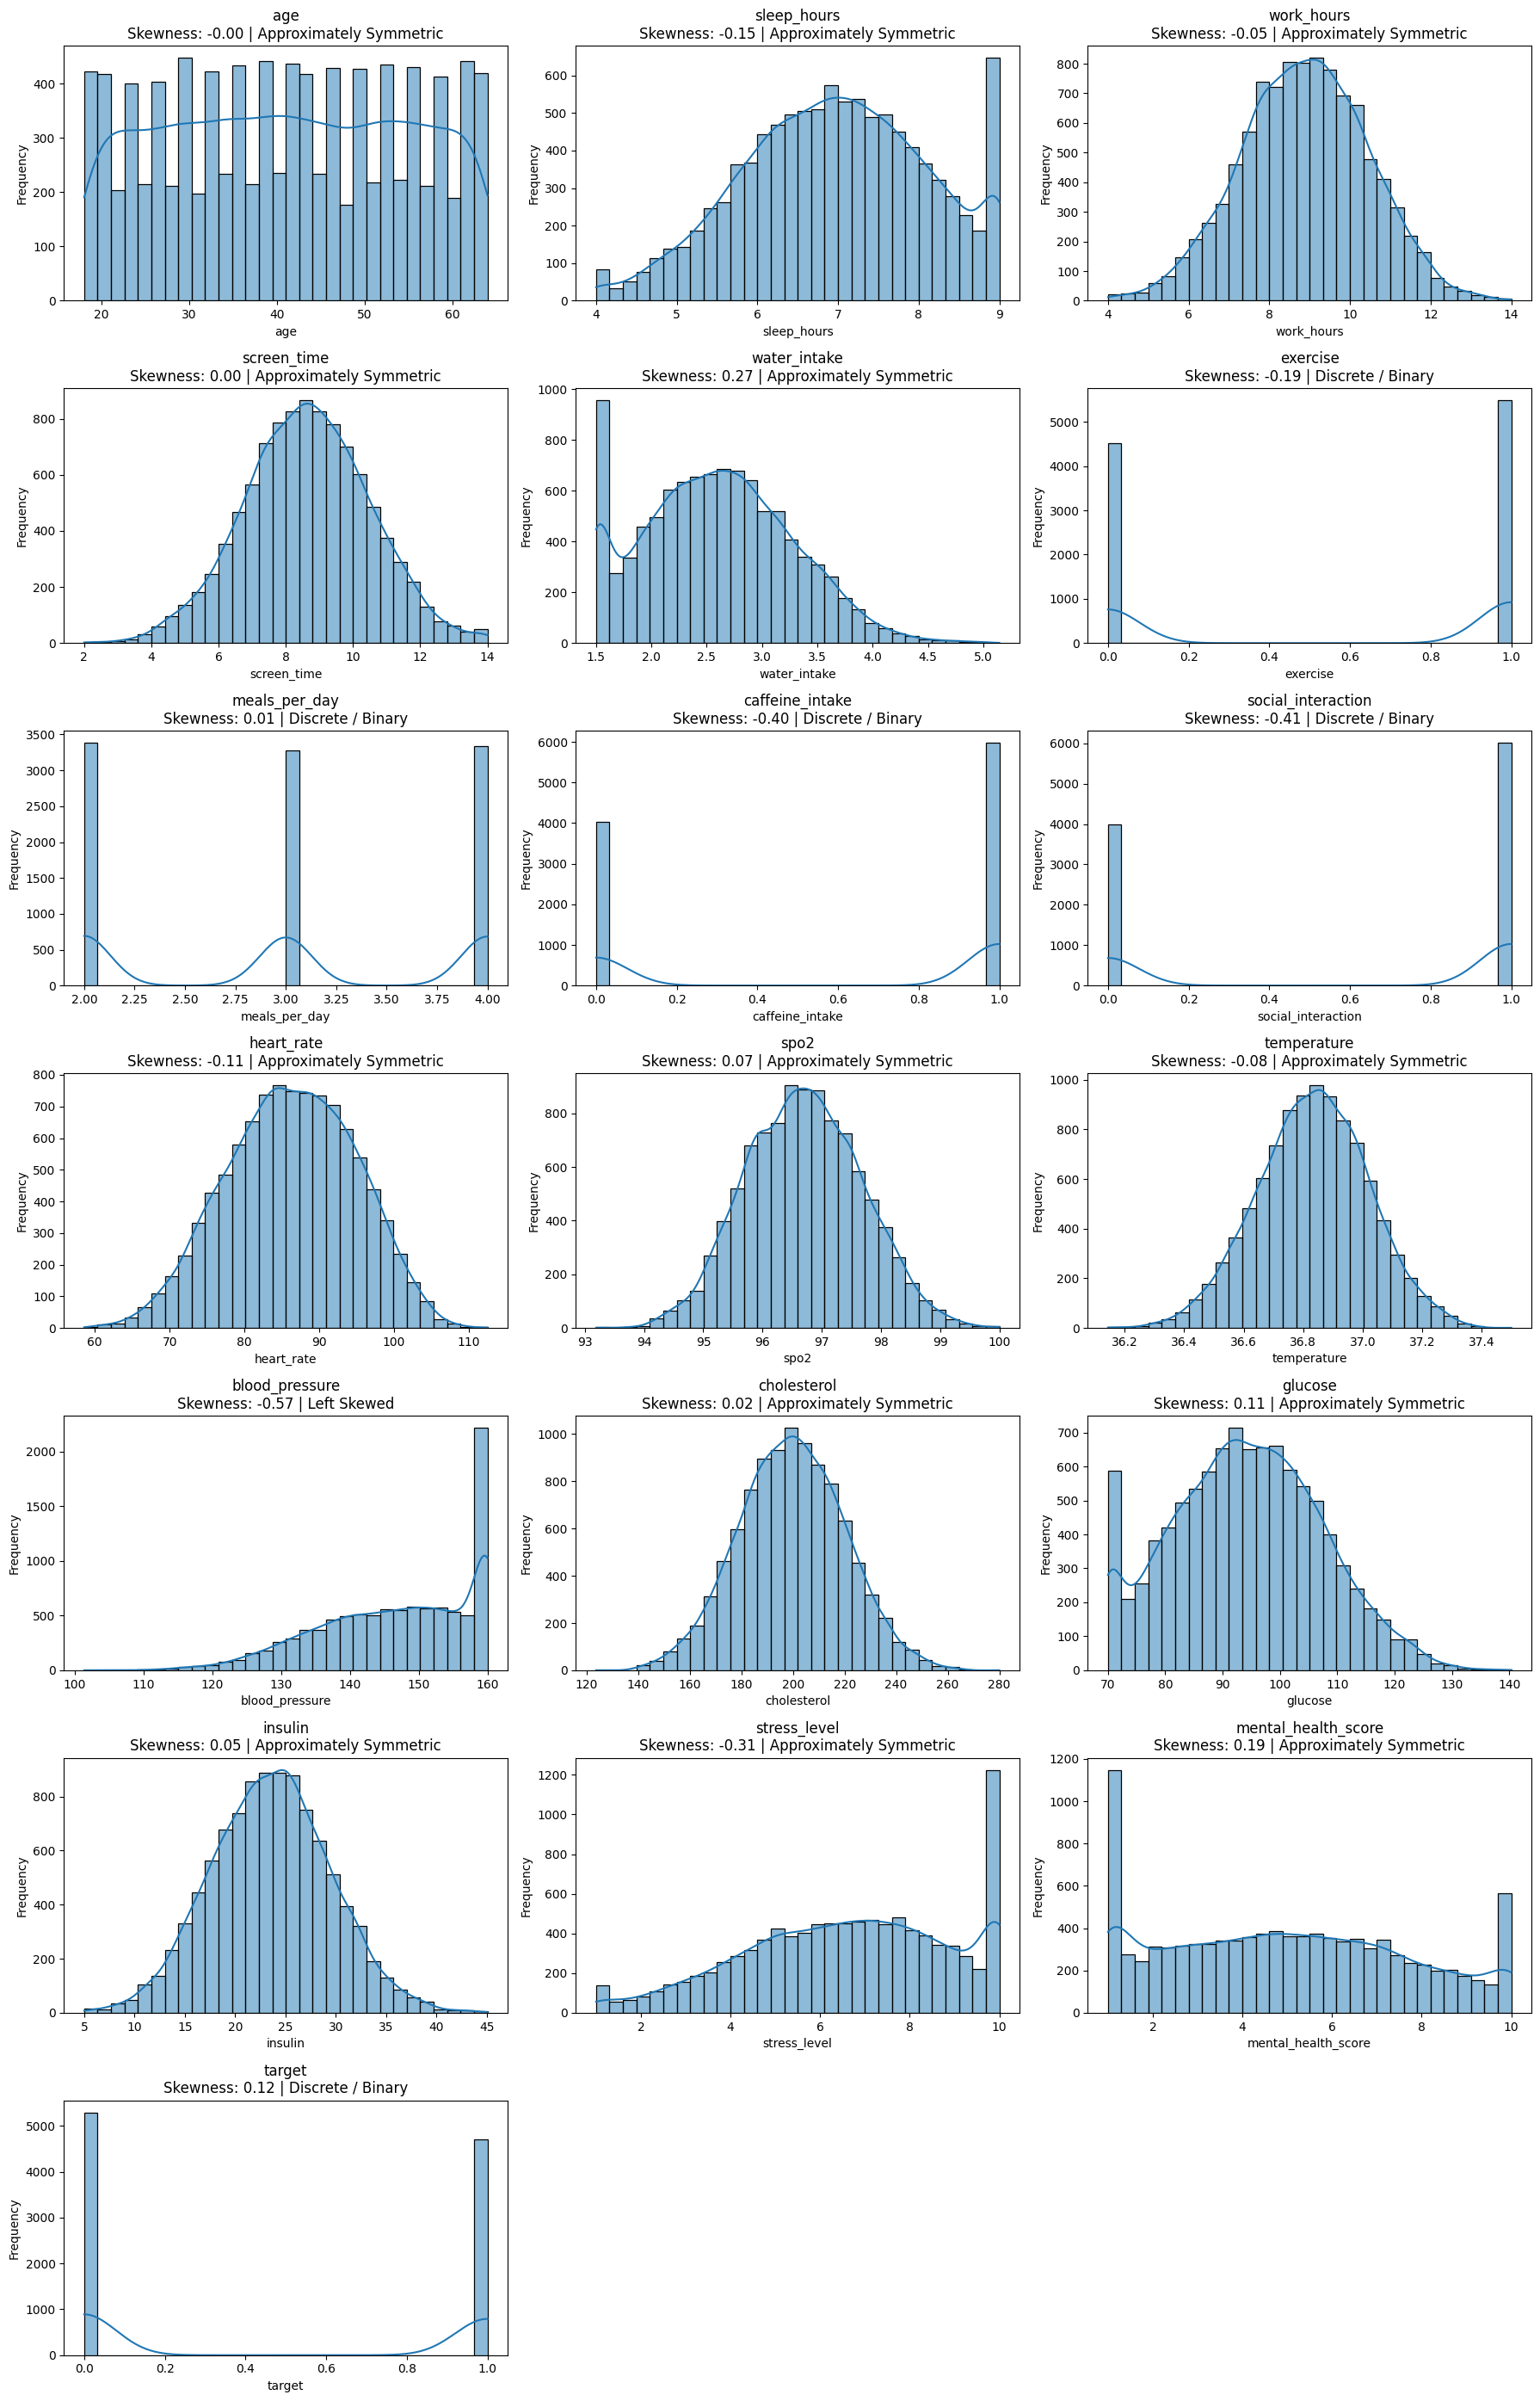


Distribution Analysis:
            Feature  Skewness            Distribution
                age    -0.000 Approximately Symmetric
        sleep_hours    -0.155 Approximately Symmetric
         work_hours    -0.052 Approximately Symmetric
        screen_time     0.002 Approximately Symmetric
       water_intake     0.275 Approximately Symmetric
           exercise    -0.194       Discrete / Binary
      meals_per_day     0.008       Discrete / Binary
    caffeine_intake    -0.398       Discrete / Binary
 social_interaction    -0.413       Discrete / Binary
         heart_rate    -0.109 Approximately Symmetric
               spo2     0.066 Approximately Symmetric
        temperature    -0.083 Approximately Symmetric
     blood_pressure    -0.566             Left Skewed
        cholesterol     0.019 Approximately Symmetric
            glucose     0.110 Approximately Symmetric
            insulin     0.050 Approximately Symmetric
       stress_level    -0.305 Approximately Symmetric
ment

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Function to classify distribution
def classify_distribution(series):
    # Discrete / categorical-like feature
    if series.nunique() <= 5:
        return "Discrete / Binary"

    skew = series.skew()

    if abs(skew) < 0.5:
        return "Approximately Symmetric"
    elif skew >= 0.5:
        return "Right Skewed"
    else:
        return "Left Skewed"


# Create plots
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(18, n_rows * 4))

results = []

for i, col in enumerate(numeric_cols, 1):

    skew = df[col].skew()
    distribution = classify_distribution(df[col])

    results.append({
        "Feature": col,
        "Skewness": round(skew, 3),
        "Distribution": distribution
    })

    plt.subplot(n_rows, n_cols, i)

    sns.histplot(
        df[col],
        kde=True,
        bins=30
    )

    # Title with distribution information
    plt.title(
        f"{col}\n"
        f"Skewness: {skew:.2f} | {distribution}"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# Create summary table
distribution_df = pd.DataFrame(results)

print("\nDistribution Analysis:")
print(distribution_df.to_string(index=False))

In [57]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

for col in num_cols:
    count, low, up = detect_outliers_iqr(df[col])
    print(f"{col:30s} outliers = {count:5d}  (range {low:.2f} to {up:.2f})")

age                            outliers =     0  (range -4.50 to 87.50)
sleep_hours                    outliers =     0  (range 3.71 to 10.26)
work_hours                     outliers =    62  (range 4.56 to 13.21)
screen_time                    outliers =    81  (range 3.61 to 13.68)
water_intake                   outliers =    45  (range 0.68 to 4.48)
exercise                       outliers =     0  (range -1.50 to 2.50)
meals_per_day                  outliers =     0  (range -1.00 to 7.00)
caffeine_intake                outliers =     0  (range -1.50 to 2.50)
social_interaction             outliers =     0  (range -1.50 to 2.50)
heart_rate                     outliers =    16  (range 61.78 to 111.13)
spo2                           outliers =    26  (range 93.90 to 99.47)
temperature                    outliers =    57  (range 36.33 to 37.34)
blood_pressure                 outliers =    12  (range 111.83 to 184.07)
cholesterol                    outliers =    48  (range 143.71 to 255.

In [58]:
for col in ['work_hours','screen_time','water_intake','heart_rate',
            'spo2','temperature','blood_pressure','cholesterol',
            'glucose','insulin']:
    print(col)
    print("  min:", df[col].min(), " max:", df[col].max())
    print(df[col].describe([.01,.05,.95,.99]))
    print("-"*40)

work_hours
  min: 4.0  max: 14.0
count    10000.000000
mean         8.878361
std          1.575749
min          4.000000
1%           5.202740
5%           6.236332
50%          8.899445
95%         11.426790
99%         12.427274
max         14.000000
Name: work_hours, dtype: float64
----------------------------------------
screen_time
  min: 2.0  max: 14.0
count    10000.000000
mean         8.643288
std          1.874974
min          2.000000
1%           4.312499
5%           5.538001
50%          8.639860
95%         11.727656
99%         13.117726
max         14.000000
Name: screen_time, dtype: float64
----------------------------------------
water_intake
  min: 1.5  max: 5.145746943
count    10000.000000
mean         2.595126
std          0.670972
min          1.500000
1%           1.500000
5%           1.500000
50%          2.577622
95%          3.728286
99%          4.220820
max          5.145747
Name: water_intake, dtype: float64
----------------------------------------
heart_

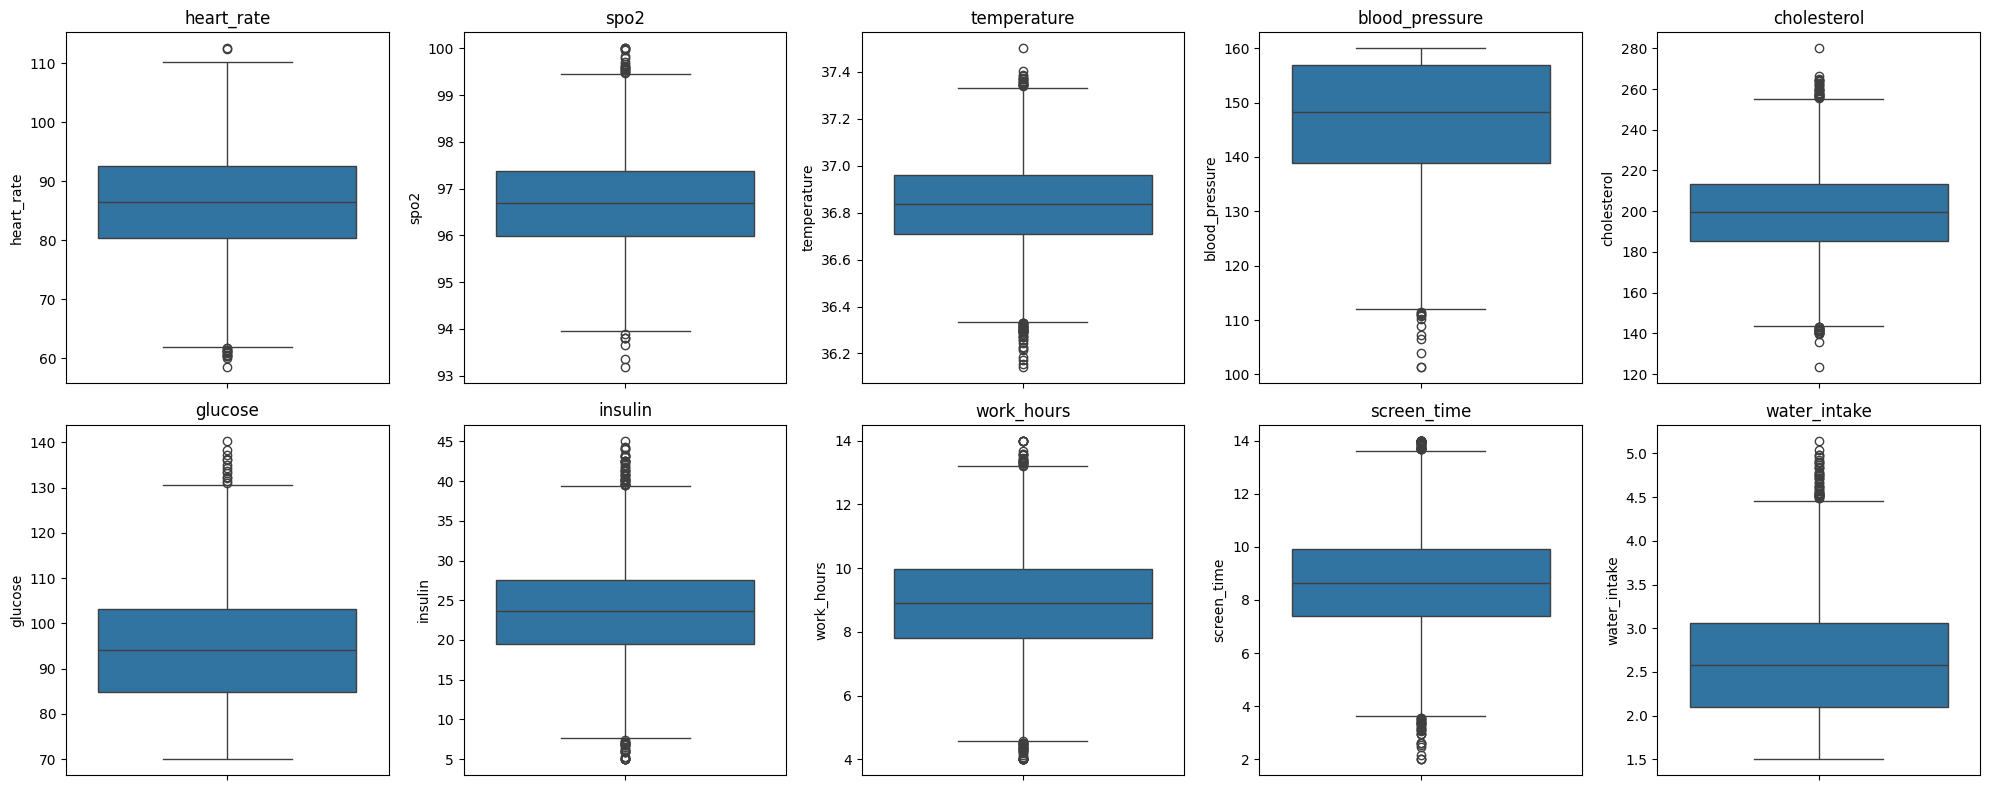

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['heart_rate','spo2','temperature','blood_pressure',
        'cholesterol','glucose','insulin','work_hours',
        'screen_time','water_intake']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for ax, c in zip(axes.flat, cols):
    sns.boxplot(y=df[c], ax=ax)
    ax.set_title(c)
plt.tight_layout()
plt.show()

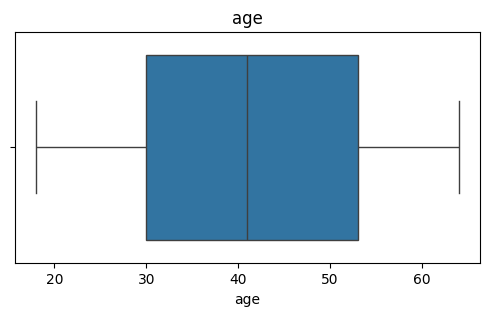

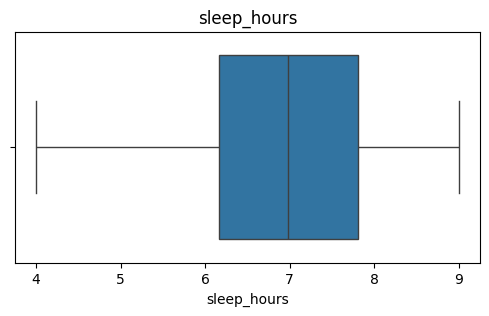

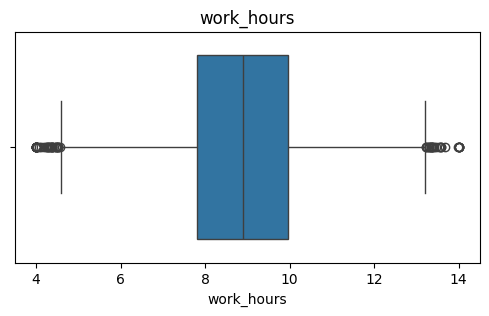

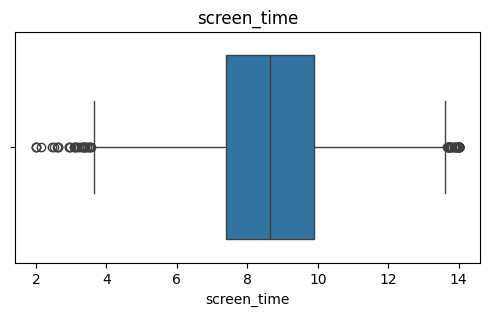

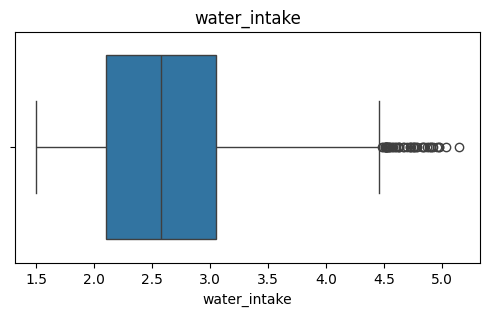

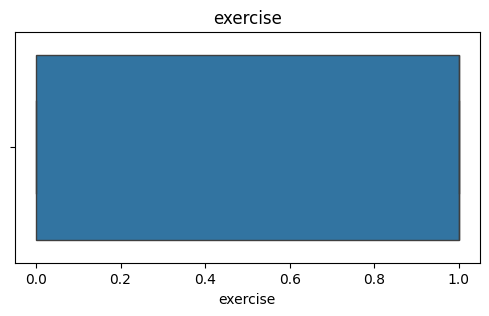

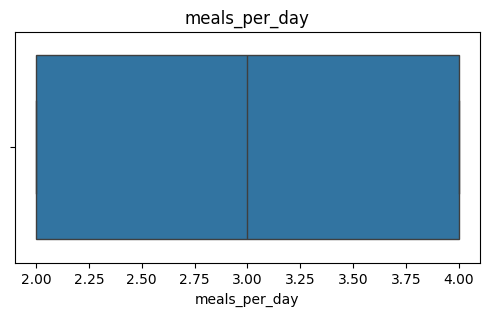

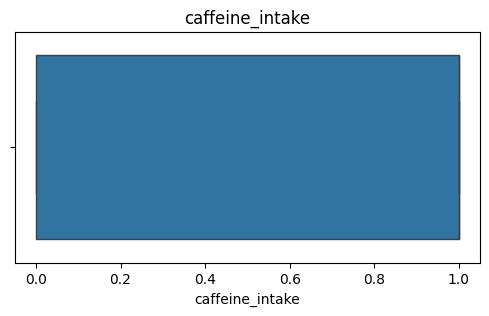

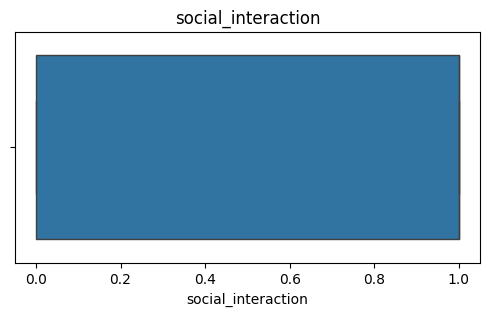

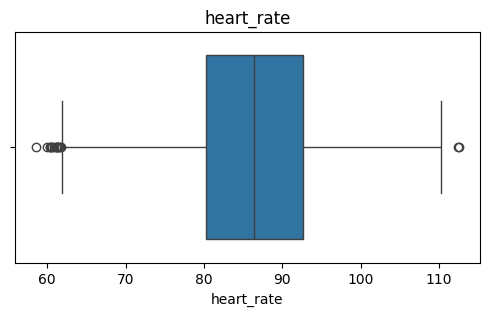

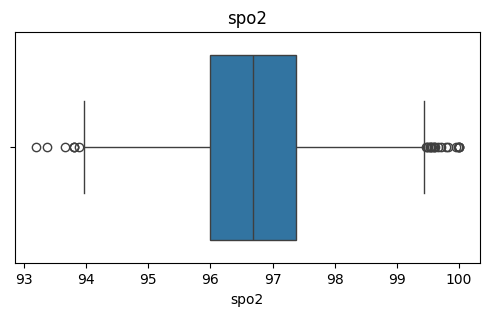

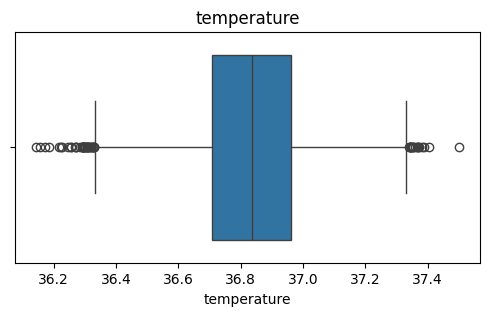

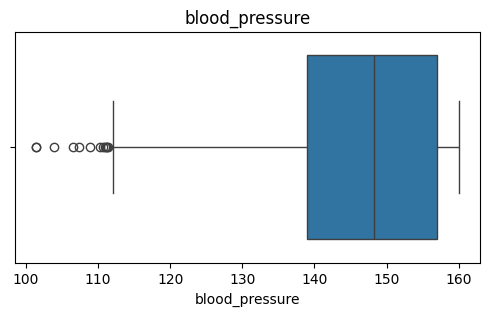

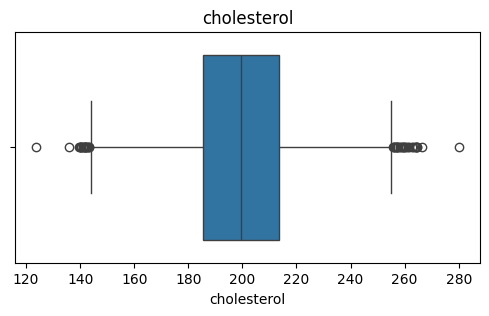

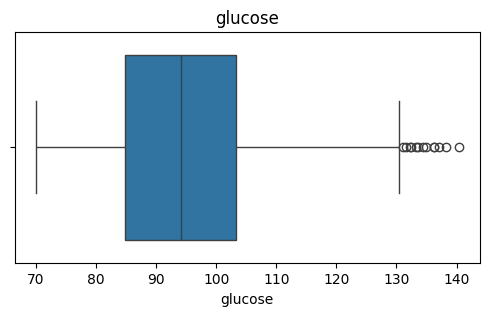

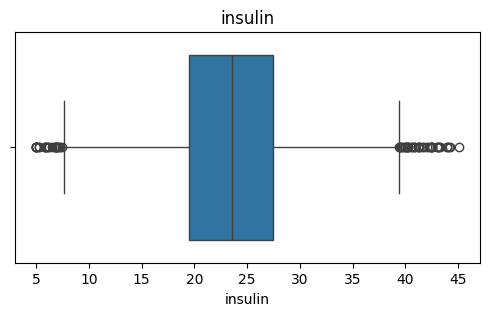

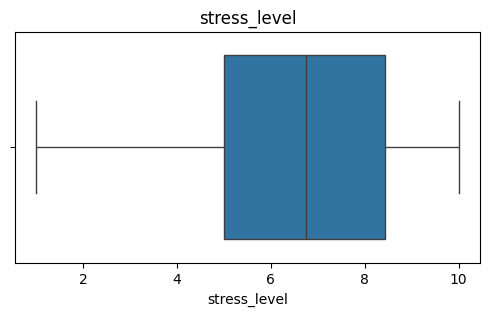

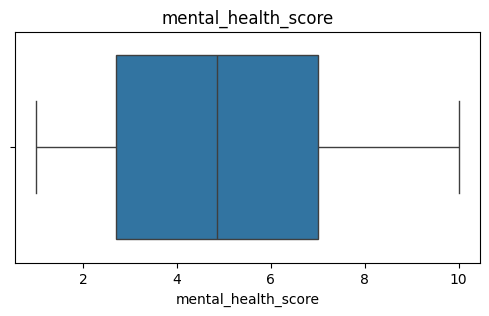

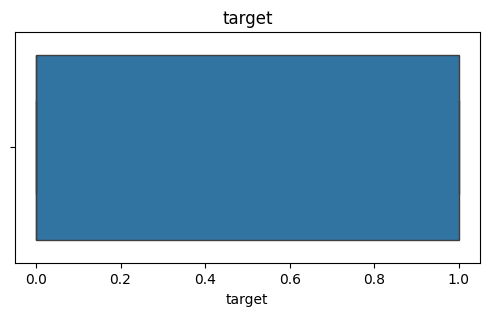

In [60]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [61]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score


X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# ---- 2. Define models ----
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=None,
        n_jobs=-1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=-1,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        random_state=42
    ),
}

# ---- 3. Cross-validate ----
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_weighted')
    print(f"{name:15s} CV F1 = {scores.mean():.4f} ± {scores.std():.4f}")

# ---- 4. Fit + evaluate on test ----
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{name:15s} Test F1 = {f1_score(y_test, pred, average='weighted'):.4f}")

RandomForest    CV F1 = 0.9995 ± 0.0005
XGBoost         CV F1 = 0.9992 ± 0.0005
[LightGBM] [Info] Number of positive: 3012, number of negative: 3388
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001604 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3373
[LightGBM] [Info] Number of data points in the train set: 6400, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.470625 -> initscore=-0.117635
[LightGBM] [Info] Start training from score -0.117635
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [62]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

import pandas as pd
imp = pd.Series(rf.feature_importances_, index=X_train.columns)
print(imp.sort_values(ascending=False))

stress_level           0.498285
mental_health_score    0.210950
heart_rate             0.117727
spo2                   0.045685
glucose                0.036634
temperature            0.023490
sleep_hours            0.019336
work_hours             0.010841
screen_time            0.007855
exercise               0.007773
blood_pressure         0.006744
insulin                0.003660
water_intake           0.002905
cholesterol            0.002887
age                    0.002245
social_interaction     0.001690
caffeine_intake        0.000715
meals_per_day          0.000579
dtype: float64


In [63]:
corr = df[['stress_level', 'mental_health_score', 'target']].corr()
print(corr['target'])

stress_level           0.819660
mental_health_score   -0.757176
target                 1.000000
Name: target, dtype: float64


In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X_2feat = df[['stress_level','mental_health_score']].dropna()
y = df['target']

score = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42),
    X_2feat, y, cv=5, scoring='f1'
).mean()
print(f"F1 with just 2 features: {score:.4f}")

F1 with just 2 features: 0.9894


In [65]:
X_clean = df.drop(columns=['target', 'stress_level', 'mental_health_score'])
y = df['target']

score = cross_val_score(
    RandomForestClassifier(n_estimators=300, random_state=42),
    X_clean, y, cv=5, scoring='f1'
).mean()
print(f"F1 without leaky features: {score:.4f}")

F1 without leaky features: 0.8876


In [72]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, classification_report


X = df.drop(columns=['target', 'stress_level', 'mental_health_score'])
y = df['target']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print("Test F1  :", f1_score(y_test, y_pred, average='weighted'))
print("Test Acc :", accuracy_score(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

new_input = pd.DataFrame([{
    'age': 30,
    'sleep_hours': 6.5,
    'work_hours': 9.0,
    'screen_time': 8.0,
    'water_intake': 2.5,
    'exercise': 2,
    'meals_per_day': 3,
    'caffeine_intake': 2,
    'social_interaction': 3,
    'heart_rate': 85,
    'spo2': 97,
    'temperature': 36.8,
    'blood_pressure': 145,
    'cholesterol': 210,
    'glucose': 105,
    'insulin': 22
}])

new_input = new_input[X.columns]

prediction = model.predict(new_input)
probability = model.predict_proba(new_input)

print("Predicted class      :", prediction[0])
print("Prediction probability:", probability[0])

Test F1  : 0.8904016314905877
Test Acc : 0.8905

Report:
               precision    recall  f1-score   support

           0       0.89      0.91      0.90      1059
           1       0.89      0.87      0.88       941

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

Predicted class      : 0
Prediction probability: [0.67333333 0.32666667]


In [73]:
import joblib

# After training your model
joblib.dump(model, "health_model.pkl")
print(" Model saved as health_model.pkl")

 Model saved as health_model.pkl


In [74]:
joblib.dump(list(X.columns), "model_columns.pkl")
print("✅ Columns saved")

✅ Columns saved


In [75]:
import joblib
import pandas as pd

# Load model + columns
model = joblib.load("health_model.pkl")
columns = joblib.load("model_columns.pkl")

# New input
new_input = pd.DataFrame([{
    'age': 30, 'sleep_hours': 6.5, 'work_hours': 9.0,
    'screen_time': 8.0, 'water_intake': 2.5, 'exercise': 2,
    'meals_per_day': 3, 'caffeine_intake': 2,
    'social_interaction': 3, 'heart_rate': 85, 'spo2': 97,
    'temperature': 36.8, 'blood_pressure': 145,
    'cholesterol': 210, 'glucose': 105, 'insulin': 22
}])

# Match column order
new_input = new_input[columns]

# Predict
pred = model.predict(new_input)
prob = model.predict_proba(new_input)

print("Prediction :", pred[0])
print("Probability:", prob[0])

Prediction : 0
Probability: [0.67333333 0.32666667]
